In [1]:
import sys
import os
from pathlib import Path

ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(ROOT))

print("Añadido al path:", ROOT)

Añadido al path: C:\Users\harra\c2526-R2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.exceptions as px
import folium
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)

In [ ]:
import io
import os
import matplotlib.pyplot as plt

from src.utils.funciones_minio import crear_cliente_minio, bajar_minio,bajar_mapa_minio
from src.config import PATH_PRIMARIOS_LIMPIO

OBJ_VIVIENDAS_VENTA = "viviendas_venta"
OBJ_VIVIENDAS_ALQUILER = "viviendas_alquiler"


In [ ]:
client = crear_cliente_minio()

In [ ]:
df_venta = bajar_mapa_minio(client, "rejillas", OBJ_VIVIENDAS_VENTA)
if not isinstance(df_venta, pd.DataFrame):
        df_venta = pd.read_parquet(io.BytesIO(df_venta))
df_alquiler = bajar_mapa_minio(client, "rejillas", OBJ_VIVIENDAS_ALQUILER)
if not isinstance(df_alquiler, pd.DataFrame):
        df_alquiler = pd.read_parquet(io.BytesIO(df_alquiler))
gdf_barrios = bajar_mapa_minio(client,"rejillas","barrios")
gdf_secciones = bajar_mapa_minio(client,"rejillas","secciones censales")
gdf_hexagonos_g = bajar_mapa_minio(client,"rejillas","hexagonos_1")
gdf_hexagonos_p = bajar_mapa_minio(client,"rejillas","hexagonos_2")

In [ ]:
print(df_venta.head())
print(df_alquiler.head())

          id                                         Nombre    Barrio  \
0  110289316          Ático en venta en Calle de Manzanares  Imperial   
1  110239661                  Ático en venta en Calle Ariel   Legazpi   
2  110138264                  Ático en venta en Calle Ariel   Legazpi   
3  109895689  Piso en venta en Calle Teresa López Valcárcel   Legazpi   
4  109688685                     Piso en venta en CL Toledo   Acacias   

     Distrito                         Calle   Precio  Superficie  \
0  Arganzuela           Calle de Manzanares  1299000         148   
1  Arganzuela                   Calle Ariel  1395000         217   
2  Arganzuela                   Calle Ariel  1395000         194   
3  Arganzuela  Calle Teresa López Valcárcel   880000          83   
4  Arganzuela                     CL TOLEDO   729000         111   

   Num_habitaciones  Banyos  Planta  Ventanas  Ascensor  Terraza  Balcon  \
0                 3       2     4.0  exterior      True     True   False   


In [ ]:
def resumen_estadistico(df, nombre):
    print(f"\n===== {nombre.upper()} =====")
    print(df[["Precio", "Superficie", "Precio_m2"]].describe())
    
    print("\nAsimetría:")
    print(df[["Precio", "Superficie", "Precio_m2"]].skew())
    
    print("\nCurtosis:")
    print(df[["Precio", "Superficie", "Precio_m2"]].kurt())

resumen_estadistico(df_venta, "ventas")
resumen_estadistico(df_alquiler, "alquiler")


===== VENTAS =====
             Precio    Superficie     Precio_m2
count  1.335400e+04  13354.000000  13354.000000
mean   9.628301e+05    124.446383   7103.179775
std    1.185587e+06    115.222030   3650.187334
min    4.700000e+04      5.000000    719.757890
25%    3.090000e+05     67.000000   4333.333330
50%    5.600000e+05     90.000000   6333.333330
75%    1.170000e+06    140.000000   9000.000000
max    2.300000e+07   2097.000000  44000.000000

Asimetría:
Precio        4.378348
Superficie    4.772201
Precio_m2     1.365588
dtype: float64

Curtosis:
Precio        34.456296
Superficie    37.827903
Precio_m2      3.780742
dtype: float64

===== ALQUILER =====
             Precio   Superficie    Precio_m2
count   9641.000000  9641.000000  9641.000000
mean    2383.441552    88.588113    28.812974
std     1833.520169    64.968337    12.807809
min      575.000000    10.000000     1.000000
25%     1400.000000    52.000000    21.232880
50%     1850.000000    73.000000    26.428570
75%     27

Claramente podemos obervar una alta cantidad de outliers hacia la derecha, con una alta asimetría y curtosis, así como con una mediana mucho más representativa que la media.

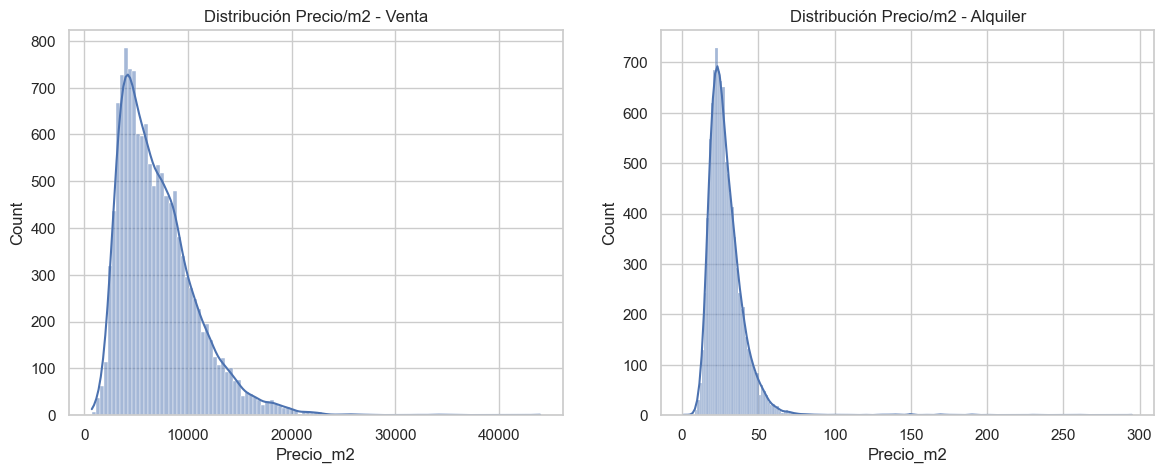

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df_venta["Precio_m2"], kde=True, ax=axes[0])
axes[0].set_title("Distribución Precio/m2 - Venta")

sns.histplot(df_alquiler["Precio_m2"], kde=True, ax=axes[1])
axes[1].set_title("Distribución Precio/m2 - Alquiler")

plt.show()

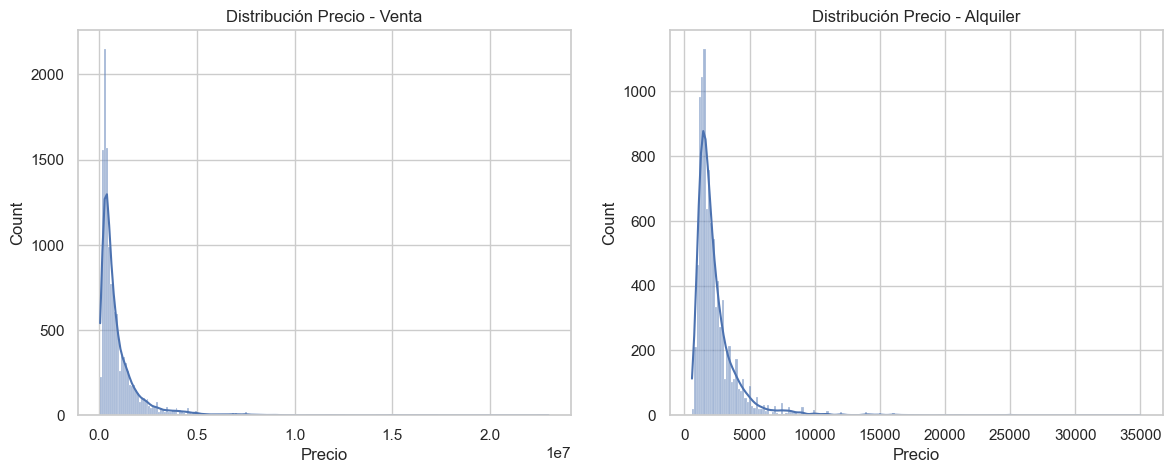

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df_venta["Precio"], kde=True, ax=axes[0])
axes[0].set_title("Distribución Precio - Venta")

sns.histplot(df_alquiler["Precio"], kde=True, ax=axes[1])
axes[1].set_title("Distribución Precio - Alquiler")

plt.show()

Vemos que los precios tienden a la normalidad, si bien muy hacia la izquierda debido a los previamente mencionados outliers

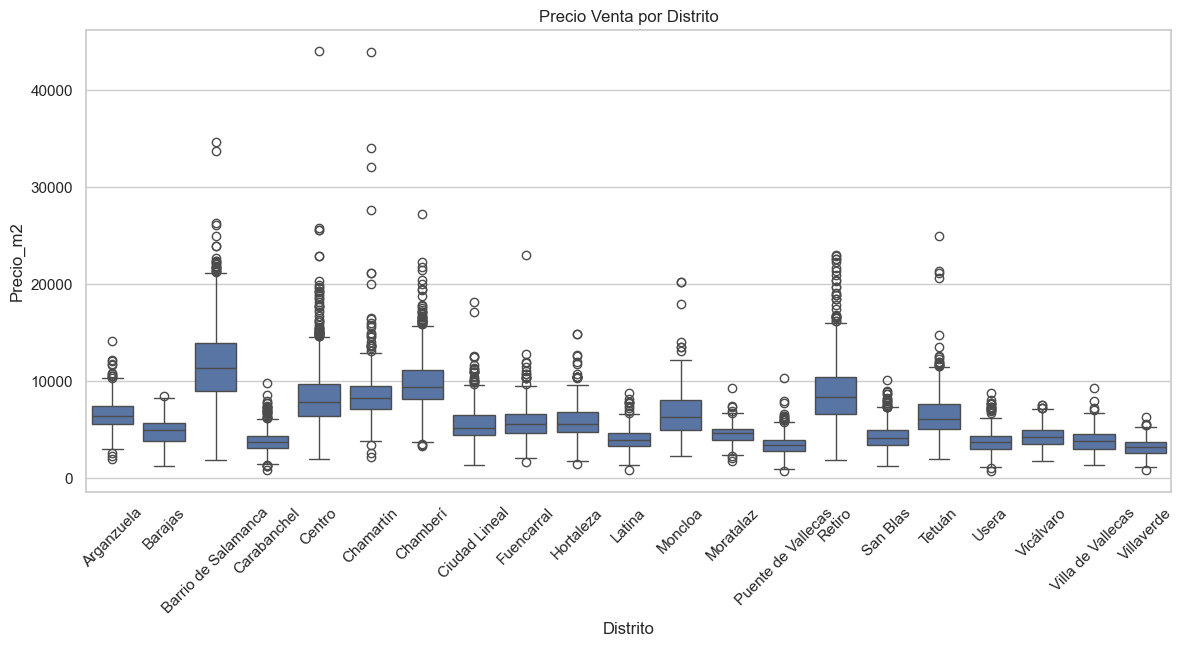

In [ ]:
top_barrios = df_venta["Distrito"].value_counts().index

plt.figure(figsize=(14,6))
sns.boxplot(data=df_venta[df_venta["Distrito"].isin(top_barrios)],
            x="Distrito", y="Precio_m2")

plt.xticks(rotation=45)
plt.title("Precio Venta por Distrito")
plt.show()

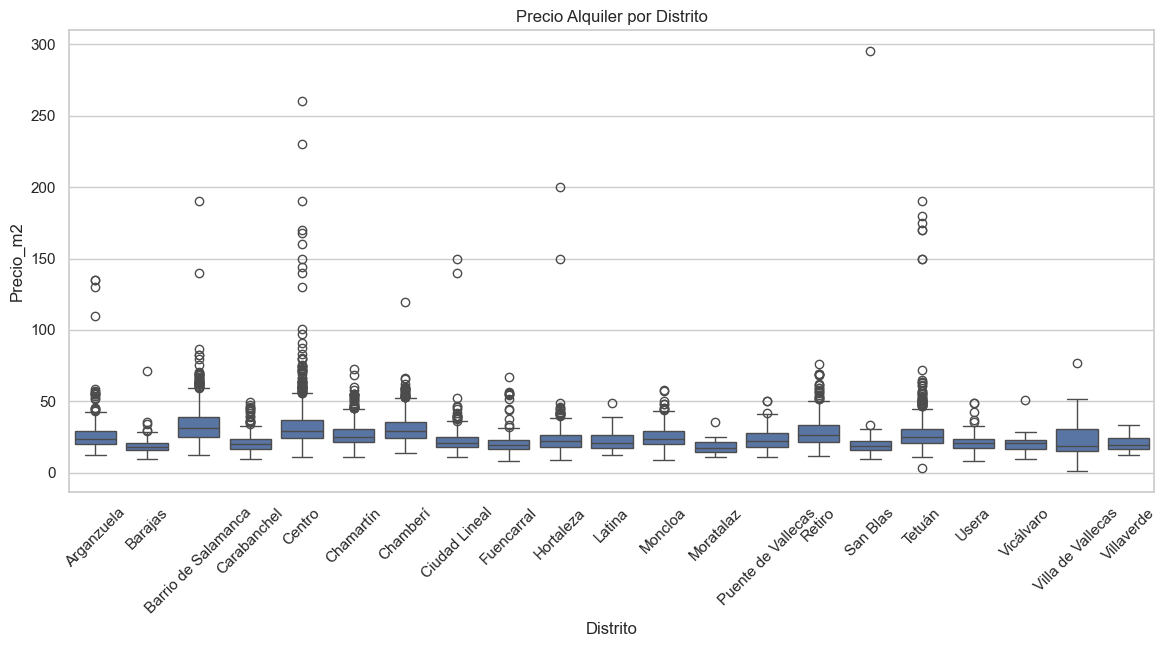

In [ ]:
top_barrios = df_alquiler["Distrito"].value_counts().index

plt.figure(figsize=(14,6))
sns.boxplot(data=df_alquiler[df_alquiler["Distrito"].isin(top_barrios)],
            x="Distrito", y="Precio_m2")

plt.xticks(rotation=45)
plt.title("Precio Alquiler por Distrito")
plt.show()

Aquí tenemos una visualización más clara de los outliers, así como de los distritos de Madrid que claramente presentan precios más altos y más bajos

In [ ]:
columnas_numerias = ["Precio","Num_habitaciones","anio_construccion","Banyos","Superficie","cantidad_alimentacion_cerca","cantidad_bomberos_cerca","cantidad_cementerios_cerca","cantidad_centros_dia_cerca","cantidad_centros_educativos_cerca","cantidad_centros_mayores_cerca","cantidad_comercios_cerca","cantidad_comisarias_cerca","cantidad_hospitales_cerca","cantidad_iglesias_cerca","cantidad_negativos_cerca","cantidad_parques_cerca","cantidad_piscinas_cerca","cantidad_puntos_limpios_cerca","cantidad_servicios_sociales_cerca","cantidad_universidades_cerca","paradas_cerca","lineas_distintas_paradas_cerca","estaciones_cerca","lineas_distintas_estaciones_cerca"]

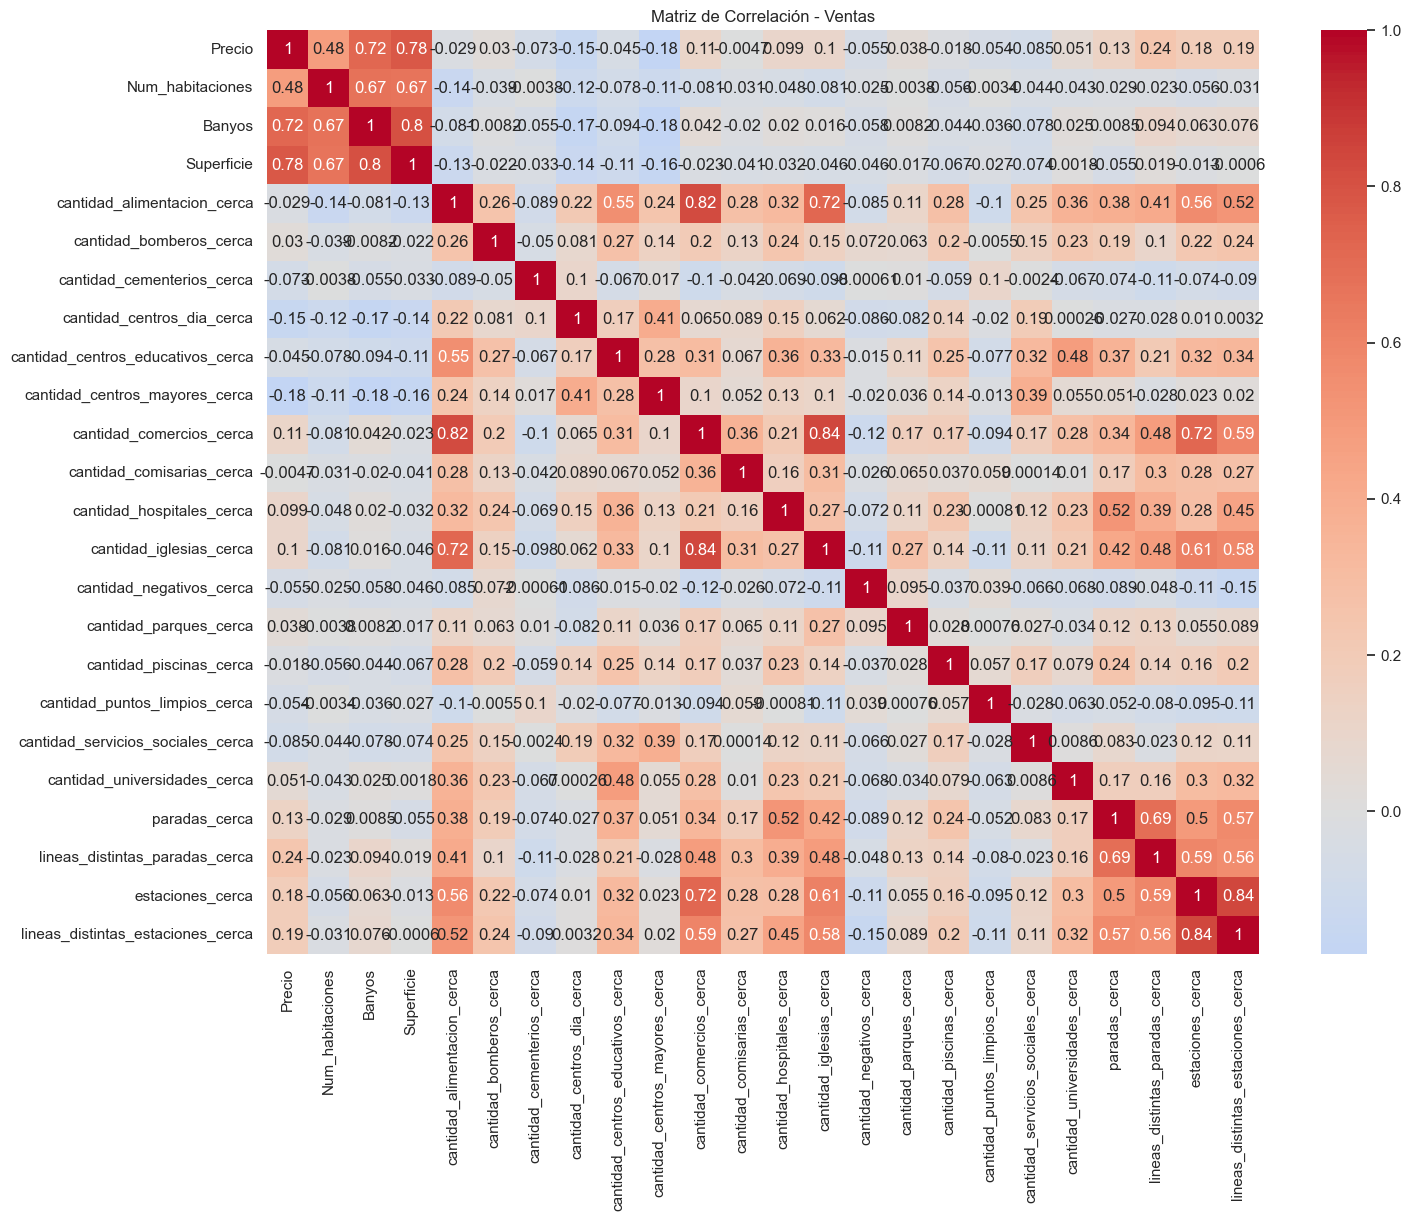

In [ ]:
corr_ventas = df_venta[columnas_numerias].corr(numeric_only=True)

plt.figure(figsize=(16,12))
sns.heatmap(corr_ventas, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación - Ventas")
plt.show()

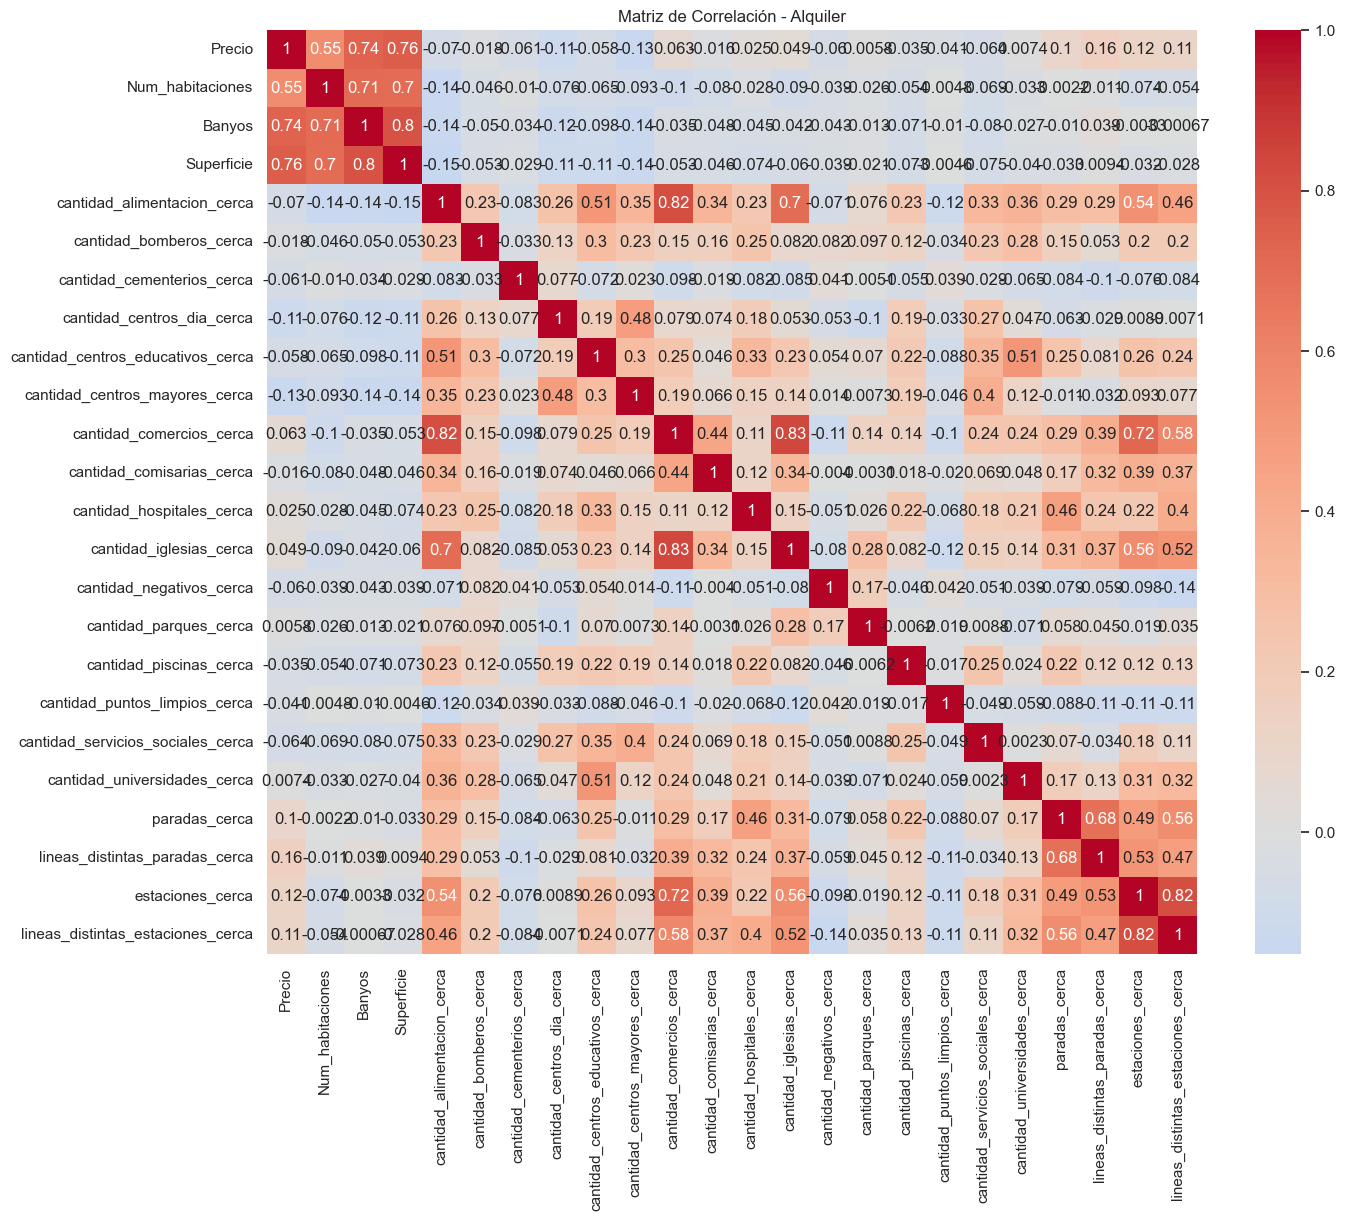

In [ ]:
corr_alquiler = df_alquiler[columnas_numerias].corr(numeric_only=True)

plt.figure(figsize=(15,12))
sns.heatmap(corr_alquiler, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación - Alquiler")
plt.show()

Aquí la correlación más clara se da entre el precio, la superficie, el número de habitaciones y los baños. También vemos correlación mínima en caso de tener ascensor o balcón, aunque esto también puede ser debido a que a mayor tamaño de la vivienda, mayor probabilidad de que tenga múltiples pisos.

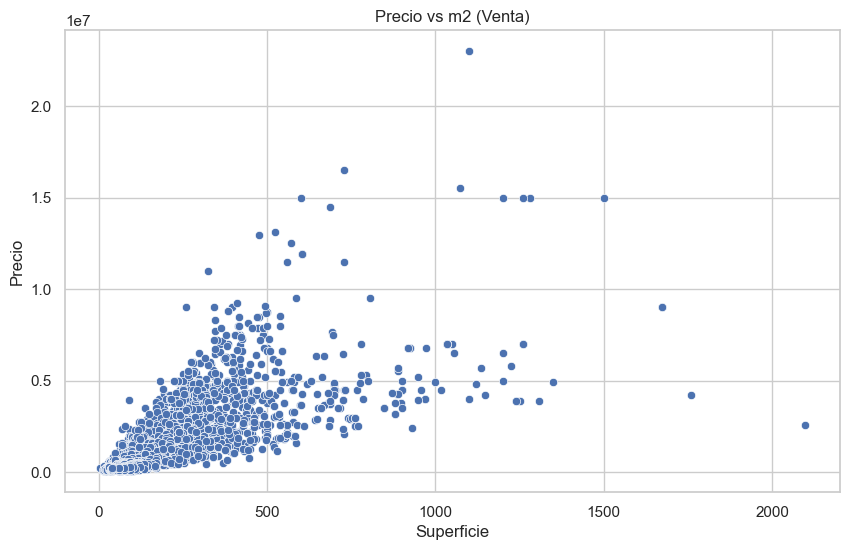

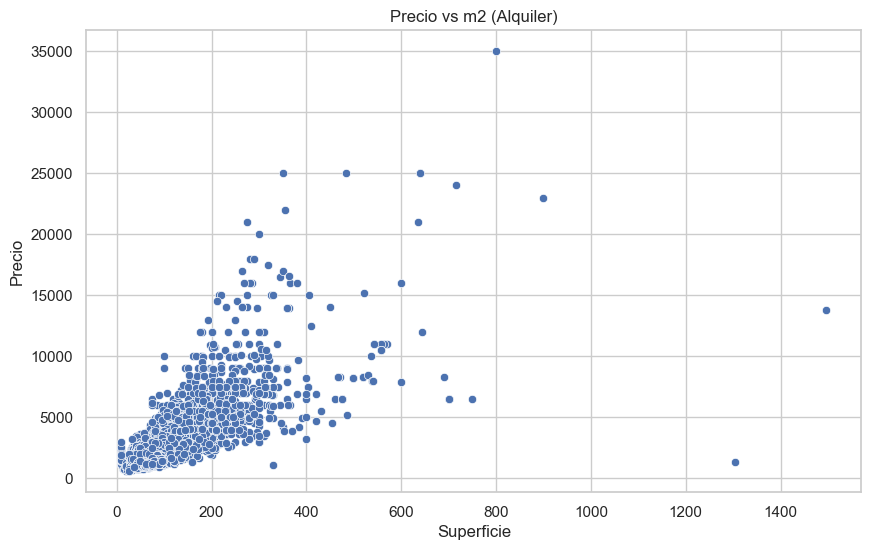

In [ ]:
sns.scatterplot(data=df_venta, x="Superficie", y="Precio")
plt.title("Precio vs m2 (Venta)")
plt.show()

sns.scatterplot(data=df_alquiler, x="Superficie", y="Precio")
plt.title("Precio vs m2 (Alquiler)")
plt.show()

In [ ]:
import plotly.express as px


tabla = df_venta.groupby("Distrito",as_index=False)["Precio_m2"].mean()
tabla = tabla.sort_values(by="Precio_m2",ascending=True)

fig = px.bar(tabla,x="Precio_m2",y="Distrito",orientation='h',
             title="Precio de venta por m2 de los distritos de madrid",
             labels = {"Precio_m2":"Precio Medio (€/m²)","Distrito":"Distrito"},
             color = "Precio_m2",
             color_continuous_scale="Plasma"
             )

fig.update_layout(
        template='plotly_white',
        height=700,
        xaxis_title="Precio Medio (€/m²)",
        yaxis_title=""
    )

fig.update_traces(textposition='outside')
fig.show(renderer="browser")

In [ ]:
tabla = df_alquiler.groupby("Distrito",as_index=False)["Precio_m2"].mean()
tabla = tabla.sort_values(by="Precio_m2",ascending=True)

fig = px.bar(tabla,x="Precio_m2",y="Distrito",orientation='h',
             title="Precio de alquiler por m2 de los distritos de madrid",
             labels = {"Precio_m2":"Precio Medio (€/m²)","Distrito":"Distrito"},
             color = "Precio_m2",
             color_continuous_scale="Viridis"
             )

fig.update_layout(
        template='plotly_white',
        height=700,
        xaxis_title="Precio Medio (€/m²)",
        yaxis_title=""
    )

fig.update_traces(textposition='outside')
fig.show(renderer="browser")

Aquí podemos ver el precio por metro cuadrático medio de cada distrito. Claramente vemos que el barrio de Salamanca, el centro de madrid y todos los Distritos que se encuentran en esa zona tienen un precio por metro cuadrático alto.

In [ ]:
Q1 = df_venta["Precio_m2"].quantile(0.25)
Q3 = df_venta["Precio_m2"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers = df_venta[df_venta["Precio_m2"] > limite_superior]

print("Número de outliers:", len(outliers))

Número de outliers: 341


In [ ]:
Q1 = df_alquiler["Precio_m2"].quantile(0.25)
Q3 = df_alquiler["Precio_m2"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers = df_alquiler[df_alquiler["Precio_m2"] > limite_superior]

print("Número de outliers:", len(outliers))

Número de outliers: 305


In [ ]:
stat, p = stats.shapiro(df_venta["Precio_m2"].sample(500))

print("Shapiro-Wilk p-value:", p)

Shapiro-Wilk p-value: 1.9855927131361918e-15


In [ ]:
stat, p = stats.shapiro(df_alquiler["Precio_m2"].sample(500))

print("Shapiro-Wilk p-value:", p)

Shapiro-Wilk p-value: 8.792252767817897e-33


# Mapas

In [ ]:
import tempfile
import webbrowser
import geopandas as gpd
def visualizar_rejilla(gdf:gpd.GeoDataFrame,columna:str,lista_info:list):
    mapa_base = gdf.explore(
        column=columna,  
        cmap='YlOrRd', 
        name="Barrios (Num Tiendas)",  
        tooltip=lista_info,
        style_kwds={'fillOpacity': 0.6,'opacity': 0.8, 'color': 'black', 'weight': 1}
    )
    folium.LayerControl().add_to(mapa_base)
    with tempfile.NamedTemporaryFile(delete=False, suffix=".html") as tmp:
        mapa_base.save(tmp.name)
        ruta_temporal = tmp.name
    webbrowser.open('file://' + ruta_temporal)

### Distribución de las viviendas recogidas a la venta

In [ ]:
visualizar_rejilla(df_venta,None,["Precio","Superficie","Precio_m2","Barrio","Distrito"])

### Distribuvion de viviendas recogidas a alquilar

In [ ]:
visualizar_rejilla(df_alquiler,None,["Precio","Superficie","Precio_m2","Barrio","Distrito"])

### Heatmap del precio medio cuadrático de venta por regiones madrileñas

In [ ]:
visualizar_rejilla(gdf_barrios,'Media_precio_m2_venta',["NOMBRE","Media_precio_m2_venta"])

Tal y como vimos en el barplot, las regiones con mayor valor para el precio por metro cuadrático medio son los de barrio de salamanca, centro de madrid, retiro y alrededores.

### Densidad de comercios por sección censal

In [ ]:
visualizar_rejilla(gdf_secciones,'Densidad_comercios',["CUSEC",'Densidad_comercios'])

El conjunto de secciones censales que engloban las grandes calles comerciales madrileñas (Gran vía, calle de fuencaral, etc.) son las que tienen mayor densidad de comercios.

In [ ]:
visualizar_rejilla(gdf_hexagonos_g,"Num_estaciones",["id_hex","Num_estaciones"])